## Getting microsoft's cats and dogs database from kaggle

In [40]:
# ! pip install kaggle

In [41]:
# %%writefile kaggle.json
# {
#   "username": "sanmitragoswami",
#   "key": ""
# }

# !mkdir -p ~/.kaggle
# !mv kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [42]:
# !kaggle datasets list ## test if kaggle loaded
# !kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset
# !unzip microsoft-catsvsdogs-dataset.zip
# !ls

## Python Imports

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, UnidentifiedImageError

## Data Preparation

In [44]:
# Data Augmentation for Training
# Compose means apply these transforms in order one after the other
train_transforms = transforms.Compose([
    transforms.Resize(256), # shorter side to 256 pixels
    transforms.CenterCrop(224), # randomly crops 224*224 patch from this
    transforms.RandomHorizontalFlip(), # randomly flips img laterally with 0.5 prob
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    transforms.ToTensor(), # converts img to pytorch tensor output shape becomes (c,h,w)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 # image net normalisation
])

In [45]:
# No Augmentation for Validation/Test
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Manual Split of Full Data

In [46]:
# import os

# base = "data"
# for split in ["train", "val", "test"]:
#     for cls in ["Cat", "Dog"]:
#         os.makedirs(f"{base}/{split}/{cls}", exist_ok=True)
# import random
# import shutil

# def split_class(class_name):
#     src = f"PetImages/{class_name}"
#     files = os.listdir(src)
#     random.shuffle(files)

#     n = len(files)
#     train_end = int(0.8 * n)
#     val_end = int(0.9 * n)

#     splits = {
#         "train": files[:train_end],
#         "val": files[train_end:val_end],
#         "test": files[val_end:]
#     }

#     for split, split_files in splits.items():
#         for f in split_files:
#             shutil.copy(
#                 os.path.join(src, f),
#                 f"data/{split}/{class_name}/{f}"
#             )

# split_class("Cat")
# split_class("Dog")


In [ ]:
# Custom loader to handle UnidentifiedImageError
def custom_pil_loader(path):
    try:
        with open(path, 'rb') as f:
            img = Image.open(f).convert('RGB')
        return img
    except (UnidentifiedImageError, OSError) as e:
        print(f"Warning: Could not load image {path}. Error: {e}. Returning a black image placeholder.")
        # Return a black image of expected size (e.g., 224x224 RGB) as a placeholder
        # This assumes the target image size after transforms is 224x224.
        # If transforms include resizing, this might need adjustment or a more complex collate_fn.
        return Image.new('RGB', (224, 224), (0, 0, 0))


base_dir = "C:\\Users\\SANMITRA\\The Multiverse\\Programming Stuff\\jupyter NB\\CV basics\\data\\data"
# Load Datasets
train_data = datasets.ImageFolder(os.path.join(base_dir, 'train'), transform=train_transforms, loader=custom_pil_loader)
val_data = datasets.ImageFolder(os.path.join(base_dir, 'val'), transform=val_transforms, loader=custom_pil_loader)

In [ ]:
# Create Data Loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")

Train data size: 4000
Validation data size: 400
Test data size: 400


## Model Setup

In [49]:
# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False
# Replace the last fully connected layer with a new one for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
# Move to GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Using device: {device}")
print(f"Training only Final Layer with {model.fc.in_features} output to 2")

Using device: cpu
Training only Final Layer with 512 output to 2


## Training Setup

In [50]:
# Loss and Optimiser
criterion = nn.CrossEntropyLoss()
## cross entropy loss is a loss function used for multi-class classification
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
## creates an adam optimizer, that updates only model's fully connected params

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# Training Tracking
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

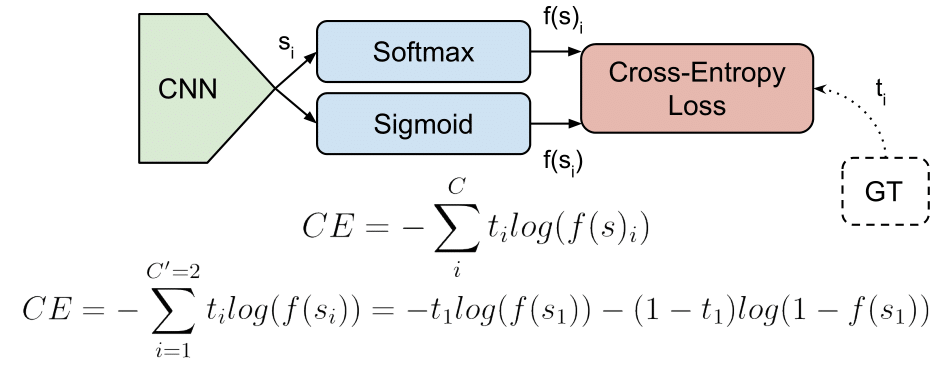

### CNN
- Takes an input image
- Extracts features through convolution + pooling
- Outputs a vector of scores (also called logits)
### $S_i$ - Logits
- It's the raw output of the CNN for class i
- Can be any real number: +ve, -ve, large, small
- Needs an activation function to convert to probabilities
### Sigmoid
used for binary or multi-class classification
$f(s_i)$
### Softmax
used for multi-class classification
$f(s)_i$ = probability that input belongs to class i
### GT
ground truth



### Scheduler
- optimizer: the optimizer whose LR will be changed
- mode: (=min) so lower is better
- patience: wait n epochs if monitored value does noy improve reduce LR
- factor: newLR = factor$\times$oldLR

## Training Loop

In [51]:
n_epochs = 10
for epoch in range(n_epochs):
    # Training Phase
    model.train()
    running_losses = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        # Fwd
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        # Bck
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #Statistics
        running_losses += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_losses/len(train_loader)
    train_accuracy = 100*correct/total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation Phase
    model.eval()
    val_running_losses = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_losses += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_losses/len(val_loader)
    val_accuracy = 100*val_correct/val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    ## update learning rate
    scheduler.step(val_loss)
    ## save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Saved best model with val_accuracy: {best_val_accuracy:.2f}%")

    print(f"Epoch: [{epoch+1}/{n_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")
    print()

Saved best model with val_accuracy: 97.50%
Epoch: [1/10]
Train Loss: 0.2464, Train Accuracy: 90.62%
Val Loss: 0.0856, Val Accuracy: 97.50%

Saved best model with val_accuracy: 99.00%
Epoch: [2/10]
Train Loss: 0.1529, Train Accuracy: 93.78%
Val Loss: 0.0631, Val Accuracy: 99.00%

Epoch: [3/10]
Train Loss: 0.1271, Train Accuracy: 95.20%
Val Loss: 0.0592, Val Accuracy: 98.25%

Saved best model with val_accuracy: 99.25%
Epoch: [4/10]
Train Loss: 0.1207, Train Accuracy: 95.17%
Val Loss: 0.0459, Val Accuracy: 99.25%

Epoch: [5/10]
Train Loss: 0.1267, Train Accuracy: 94.72%
Val Loss: 0.0546, Val Accuracy: 97.50%

Epoch: [6/10]
Train Loss: 0.1115, Train Accuracy: 95.55%
Val Loss: 0.0493, Val Accuracy: 98.00%

Epoch: [7/10]
Train Loss: 0.1063, Train Accuracy: 95.90%
Val Loss: 0.0434, Val Accuracy: 98.25%



KeyboardInterrupt: 

In [52]:
np.save("train_losses.npy", train_losses)
np.save("val_losses.npy", val_losses)
np.save("val_accuracies.npy", val_accuracies)
np.save("train_accuracies.npy", train_accuracies)

## Evaluation on Test Set

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torchvision import models, transforms, datasets
from PIL import Image, UnidentifiedImageError
from torch.utils.data import DataLoader

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:

# Custom loader to handle UnidentifiedImageError
def custom_pil_loader(path):
    try:
        with open(path, 'rb') as f:
            img = Image.open(f).convert('RGB')
        return img
    except (UnidentifiedImageError, OSError) as e:
        print(f"Warning: Could not load image {path}. Error: {e}. Returning a black image placeholder.")
        # Return a black image of expected size (e.g., 224x224 RGB) as a placeholder
        # This assumes the target image size after transforms is 224x224.
        # If transforms include resizing, this might need adjustment or a more complex collate_fn.
        return Image.new('RGB', (224, 224), (0, 0, 0))

# No Augmentation for Validation/Test
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
base_dir = "C:\\Users\\SANMITRA\\The Multiverse\\Programming Stuff\\jupyter NB\\CV basics\\data\\data"
test_data = datasets.ImageFolder(os.path.join(base_dir, 'test'), transform=val_transforms, loader=custom_pil_loader)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Test data size: {len(test_data)}")

## load training curve data
train_losses = np.load("train_losses.npy").tolist()
train_accuracies = np.load("train_accuracies.npy").tolist()
val_losses = np.load("val_losses.npy").tolist()
val_accuracies = np.load("val_accuracies.npy").tolist()



In [ ]:
os.chdir("C:\\Users\\SANMITRA\\GitHubRepos\\CV-stuff\\day3-assignment")

## Load best model for evaluation
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace final layer (same as training)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# Load weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))

# Move model to device
model = model.to(device)

# Evaluation mode
model.eval()

In [ ]:
print(test_loader.dataset.root)
print(test_loader.dataset.samples[:2])

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100*correct/total
print(f"Test Accuracy: {test_accuracy:.2f}%")

C:\Users\SANMITRA\The Multiverse\Programming Stuff\jupyter NB\CV basics\data\data\test
[('C:\\Users\\SANMITRA\\The Multiverse\\Programming Stuff\\jupyter NB\\CV basics\\data\\data\\test\\cats\\cat.2200.jpg', 0), ('C:\\Users\\SANMITRA\\The Multiverse\\Programming Stuff\\jupyter NB\\CV basics\\data\\data\\test\\cats\\cat.2201.jpg', 0)]
Test Accuracy: 98.00%


.cpu(): This method moves the tensor from its current device (e.g., a GPU, represented as 'cuda') to the host system's CPU memory. This is a necessary step because NumPy is a CPU-based library and cannot directly work with data stored in GPU memory. If the tensor is already on the CPU, this method does nothing.

.numpy(): This method converts the CPU-resident PyTorch tensor into a NumPy ndarray. The resulting NumPy array and the original PyTorch tensor will share the same underlying memory, meaning that in-place modifications to the NumPy array will affect the original tensor

## Visualisation

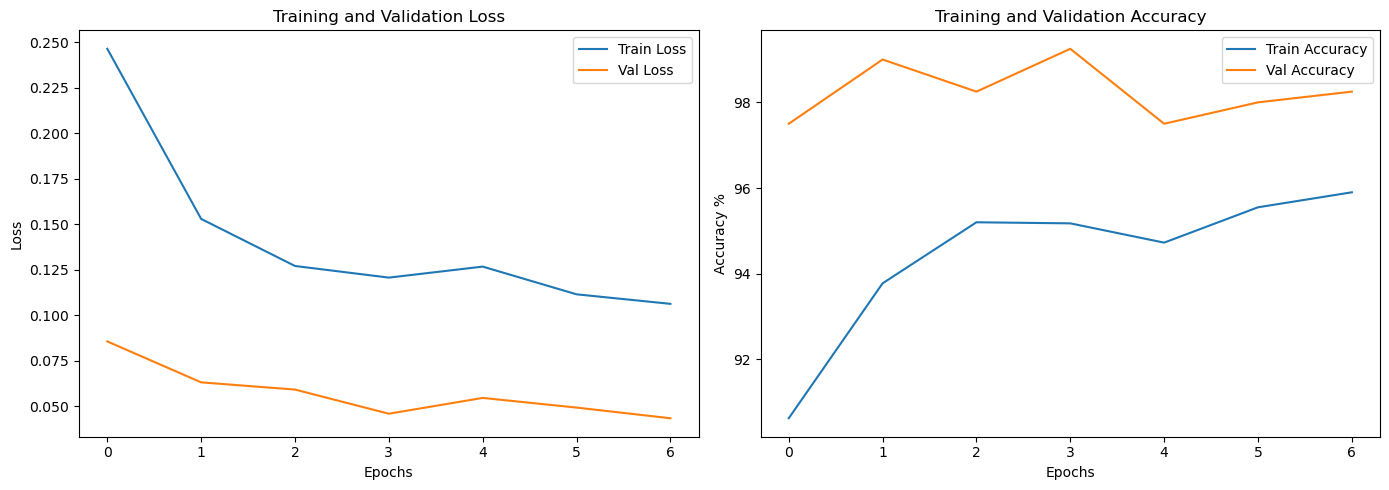

In [53]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Val Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()

ax2.plot(train_accuracies, label="Train Accuracy")
ax2.plot(val_accuracies, label="Val Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy %")
ax2.set_title("Training and Validation Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

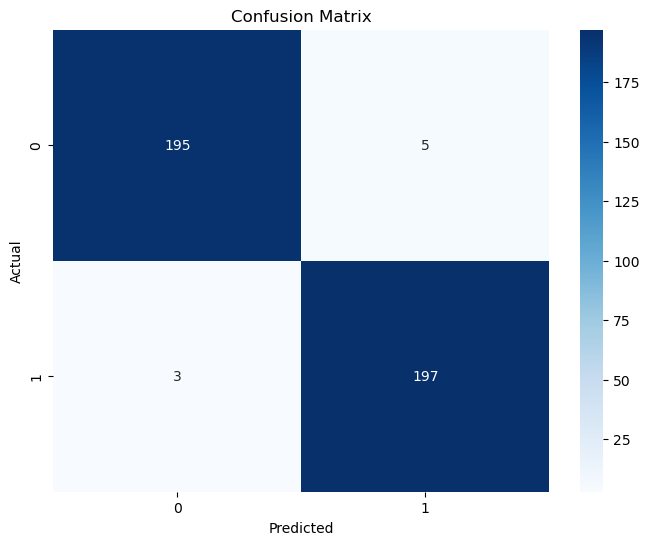

In [ ]:
# Confusion Matrix
cmatrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cmatrix, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
- annot: if True, the data value is written in each cell. Can also be a separate array for custom annotations.
- fmt: String formatting code to use when annot is True (e.g., ".2f" for two decimal places, "d" for integers).
